## Using INSPIRE with lightweight graph convolutional networks (LGCNs)

INSPIRE provides two integrative analyses options: one based on graph attention networks (GATs) and the other on lightweight graph convolutional networks (LGCNs). For tissue sections profiled using low-resolution platforms such as Visium or ST, we recommend employing the graph attention network variant of INSPIRE to leverage the attention mechanism for improved modeling accuracy. For high-resolution datasets, the lightweight graph convolutional network variant is recommended, as it provides enhanced computational efficiency and scalability for large-scale analyses.

We use the integrative analysis of mouse whole-embryo sections profiled by seqFISH and Stereo-seq as an example to provide **step-by-step instructions for applying INSPIRE with lightweight graph convolutional networks (LGCNs)**.

### Import packages

In [1]:
import numpy as np
import scanpy as sc
import umap
import INSPIRE
import warnings
warnings.filterwarnings("ignore")

### Load data

The input to INSPIRE consists of raw gene expression count matrices and spatial coordinate matrices derived from multiple tissue sections, with each section represented as an individual AnnData object. Specifically, for each tissue section, the raw count matrix is stored in adata.X, and the spatial coordinates of the spatial spots are stored in adata.obsm["spatial"].

The example seqFISH and Stereo-seq tissue sections used in this tutorial can be downloaded from [https://drive.google.com/drive/folders/1fBVZiUnUEa31-P7AMmDyQ5UPU58VnIox?usp=sharing](https://drive.google.com/drive/folders/1fBVZiUnUEa31-P7AMmDyQ5UPU58VnIox?usp=sharing).

In [2]:
data_dir = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/example_analyses/example_LGCN_data"
adata_seqfish = sc.read_h5ad(data_dir + "/adata_seqfish.h5ad")
adata_stereoseq = sc.read_h5ad(data_dir + "/adata_stereoseq.h5ad")

adata_st_list = [adata_seqfish, adata_stereoseq]

### Data preprocessing

For integrative analyses involving sections with a limited number of shared measured genes, we recommend removing non-shared genes prior to selecting num_hvgs highly variable genes per section by setting limit_num_genes=True. In this example, only 347 genes are shared between the seqFISH and Stereo-seq sections. As a result, no further feature selection is necessary, and num_hvgs is set to a value higher than the number of shared genes to avoid additional filtering. Users may adjust quality control thresholds by modifying the min_genes_qc and min_cell_qc parameters. Setting both parameters to 2 generally yields satisfactory performance when integrating sections with a limited number of shared genes. The spot_size parameter is used exclusively for visualization and determines the size of each spatial spot in the generated plots.

Get shared genes among all datasets...
Find 347 shared genes among datasets.
Finding highly variable genes...
shape of adata 0 before quality control:  (14185, 347)
shape of adata 0 after quality control:  (14185, 347)
shape of adata 1 before quality control:  (5913, 347)
shape of adata 1 after quality control:  (5880, 344)
Find 344 shared highly variable genes among datasets.
Concatenate datasets as a full anndata for better visualization...


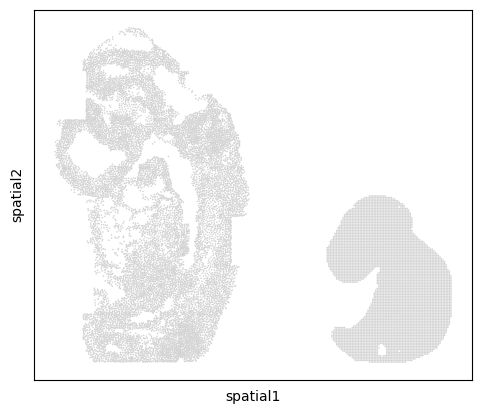

Store counts and library sizes for Poisson modeling...
Normalize data...


In [3]:
adata_st_list, adata_full = INSPIRE.utils.preprocess(adata_st_list=adata_st_list,
                                                     num_hvgs=1000,
                                                     min_genes_qc=2,
                                                     min_cells_qc=2,
                                                     spot_size=1,
                                                     limit_num_genes=True)

### Build spatial graph

INSPIRE constructs a spatial neighbor graph among spots to model spatial dependencies within each tissue section. When using the lightweight graph convolutional network (LGCN) variant, this graph is built using the INSPIRE.utils.build_graph_LGCN function, which accepts adata_st_list as input. Users can customize the radius cutoff for defining spatial neighbors in each section by modifying the values in rad_cutoff_list. In this example, we define eight natural neighbors per spot in the seqFISH section by setting the corresponding radius cutoff to 1.6. To account for differences in the scale of spatial coordinates between the two sections, we adjust the cutoff accordingly and use a value of 3 for defining spatial neighbors in the Stereo-seq section.

In [4]:
adata_st_list = INSPIRE.utils.build_graph_LGCN(adata_st_list=adata_st_list,
                                               rad_cutoff_list=[3,1.6])

Start building graphs...
Build graphs and prepare node features for LGCN networks
Radius for graph connection is 3.0000.
26.7748 neighbors per cell on average.
Node features for slice 0 : (14185, 688)
Radius for graph connection is 1.6000.
7.7946 neighbors per cell on average.
Node features for slice 1 : (5880, 688)


### Run INSPIRE model

The computational model for the LGCN variant of INSPIRE is constructed using the INSPIRE.model.Model_LGCN function, which takes adata_st_list as input. Four key parameters of this function include n_spatial_factors, n_training_steps, batch_size, and different_platforms. The n_spatial_factors parameter specifies the number of spatial factors to be inferred and should be selected based on the complexity of the tissue. A default setting of n_training_steps = 10,000 typically provides robust results. Increasing this value to 20,000 may be advantageous when modeling a larger number of spatial factors. For integrative analyses involving more than 20,000 cells or spots, we recommend setting batch_size = 2048. For datasets with fewer than 20,000 cells or spots, batch_size = 1024 is typically sufficient. The different_platforms parameter determines whether section-specific networks are used to generate spatial factors from cell or spot embeddings. When analyzing sections derived from different technologies, where strong platform-specific effects are expected, we recommend setting different_platforms = True. In all other cases, the default setting is False.

In [6]:
model = INSPIRE.model.Model_LGCN(adata_st_list=adata_st_list,
                                 n_spatial_factors=40,
                                 n_training_steps=10000,
                                 batch_size=2048,
                                 different_platforms=True
                                 )

After constructing the computational model, training is performed using the model.train function.

In [7]:
model.train(adata_st_list)

  0%|          | 6/10000 [00:00<08:30, 19.58it/s]

Step: 0, d_loss: 1.4992, Loss: 1364.8623, recon_loss: 552.5065, fe_loss: 44.9286, geom_loss: 165.7725, beta_loss: 763.3344, gan_loss: 0.7776


  5%|▌         | 506/10000 [00:12<03:39, 43.26it/s]

Step: 500, d_loss: 0.6237, Loss: 1167.3342, recon_loss: 433.0272, fe_loss: 28.1169, geom_loss: 87.4508, beta_loss: 702.1931, gan_loss: 2.2480


 10%|█         | 1006/10000 [00:23<03:29, 42.98it/s]

...

 90%|█████████ | 9006/10000 [03:31<00:24, 41.10it/s]

Step: 9000, d_loss: 0.2291, Loss: 884.2099, recon_loss: 151.7741, fe_loss: 26.0731, geom_loss: 65.6530, beta_loss: 701.6666, gan_loss: 3.3829


 95%|█████████▌| 9506/10000 [03:42<00:11, 43.67it/s]

Step: 9500, d_loss: 0.2348, Loss: 883.2949, recon_loss: 151.3600, fe_loss: 26.0523, geom_loss: 62.8923, beta_loss: 701.4165, gan_loss: 3.2083


100%|██████████| 10000/10000 [03:54<00:00, 42.66it/s]


### Access spot representations, proportions of spatial factors in spots, and gene loading matrix

After training the model, INSPIRE infers latent representations of spatial spots, spatial factors, and gene loadings using the model.eval function. This function returns two main outputs: adata_full and basis_df. The inferred latent representations of spatial spots are stored in adata_full.obsm['latent'], while the metadata indicating the section origin of each spot is saved in adata_full.obs. The spatial factor values assigned to individual spots are also stored in adata_full.obs, where adata_full.obs["Proportion of spatial factor i"] contains the proportion values corresponding to spatial factor i across all analyzed spots. The inferred gene loading matrix, shared across sections, is saved in basis_df, which is a data frame with spatial factors as rows and genes as columns.

In [8]:
adata_full, basis_df = model.eval(adata_st_list, adata_full)
basis = np.array(basis_df.values)

Add cell/spot proportions of spatial factors into adata_full.obs...
Add cell/spot latent representations into adata_full.obsm['latent']...


In [9]:
basis_df

,Abcc4,Acp5,Acvr1,Acvr2a,Adora2b,Afp,Ahnak,Akr1c19,Alas2,Aldh1a2,...,Wnt2,Wnt2b,Wnt3,Wnt3a,Wnt5a,Wnt5b,Xist,Zfp444,Zfp57,Zic3
0,0.001891,0.001366,0.002146,0.004803,0.002764,0.000217,0.010406,0.002019,0.001362,0.000272,...,0.001283,0.004060,0.002781,0.001003,0.001812,0.001912,0.005055,0.002338,0.004687,0.000627
1,0.003183,0.002417,0.003011,0.004382,0.001082,0.000150,0.002989,0.000668,0.001464,0.000549,...,0.000207,0.001333,0.000405,0.000318,0.001675,0.003486,0.002006,0.003549,0.002554,0.000395
2,0.004902,0.000600,0.003478,0.002555,0.002423,0.000247,0.000607,0.002346,0.000360,0.000188,...,0.000831,0.000727,0.001466,0.000815,0.006010,0.003184,0.005976,0.004026,0.001342,0.000686
3,0.000912,0.000695,0.001673,0.003136,0.001766,0.000839,0.001595,0.004923,0.000549,0.000417,...,0.008992,0.001814,0.001504,0.001638,0.001265,0.001916,0.002699,0.003017,0.003812,0.001313
4,0.000860,0.000530,0.001736,0.004526,0.002501,0.000344,0.002866,0.001399,0.000554,0.001668,...,0.000276,0.001178,0.000598,0.000327,0.001315,0.002891,0.002523,0.003816,0.006548,0.003307
5,0.001532,0.000907,0.003049,0.002254,0.000339,0.000186,0.010012,0.001599,0.000365,0.000450,...,0.011739,0.001445,0.000424,0.000426,0.005618,0.002162,0.002492,0.001161,0.004623,0.000281
6,0.001340,0.027123,0.001011,0.001217,0.000822,0.000343,0.001018,0.000870,0.032075,0.000470,...,0.001075,0.000731,0.000899,0.000899,0.000973,0.000759,0.001524,0.001717,0.000582,0.000385
7,0.001057,0.000748,0.002722,0.001763,0.002222,0.000770,0.005217,0.002182,0.000560,0.000417,...,0.008314,0.001125,0.001206,0.001413,0.004243,0.001064,0.002376,0.002056,0.001966,0.001516
8,0.001288,0.000757,0.002876,0.001986,0.000985,0.000337,0.000235,0.002018,0.000598,0.040546,...,0.000919,0.001234,0.001538,0.000568,0.002146,0.002673,0.002899,0.003108,0.002873,0.000436
9,0.001699,0.000830,0.002196,0.002979,0.002057,0.000231,0.008899,0.005001,0.001022,0.000505,...,0.001070,0.000792,0.003840,0.001498,0.003215,0.001984,0.001237,0.003833,0.001507,0.000757


### Spatial distributions of spatial factors in tissues

The proportion values corresponding to spatial factors across all analyzed spots are stored in adata_full.obs. These spatial patterns can be visualized using the sc.pl.spatial function from the Scanpy pipeline. The spot_size parameter controls the size of each spatial spot in the resulting plots.

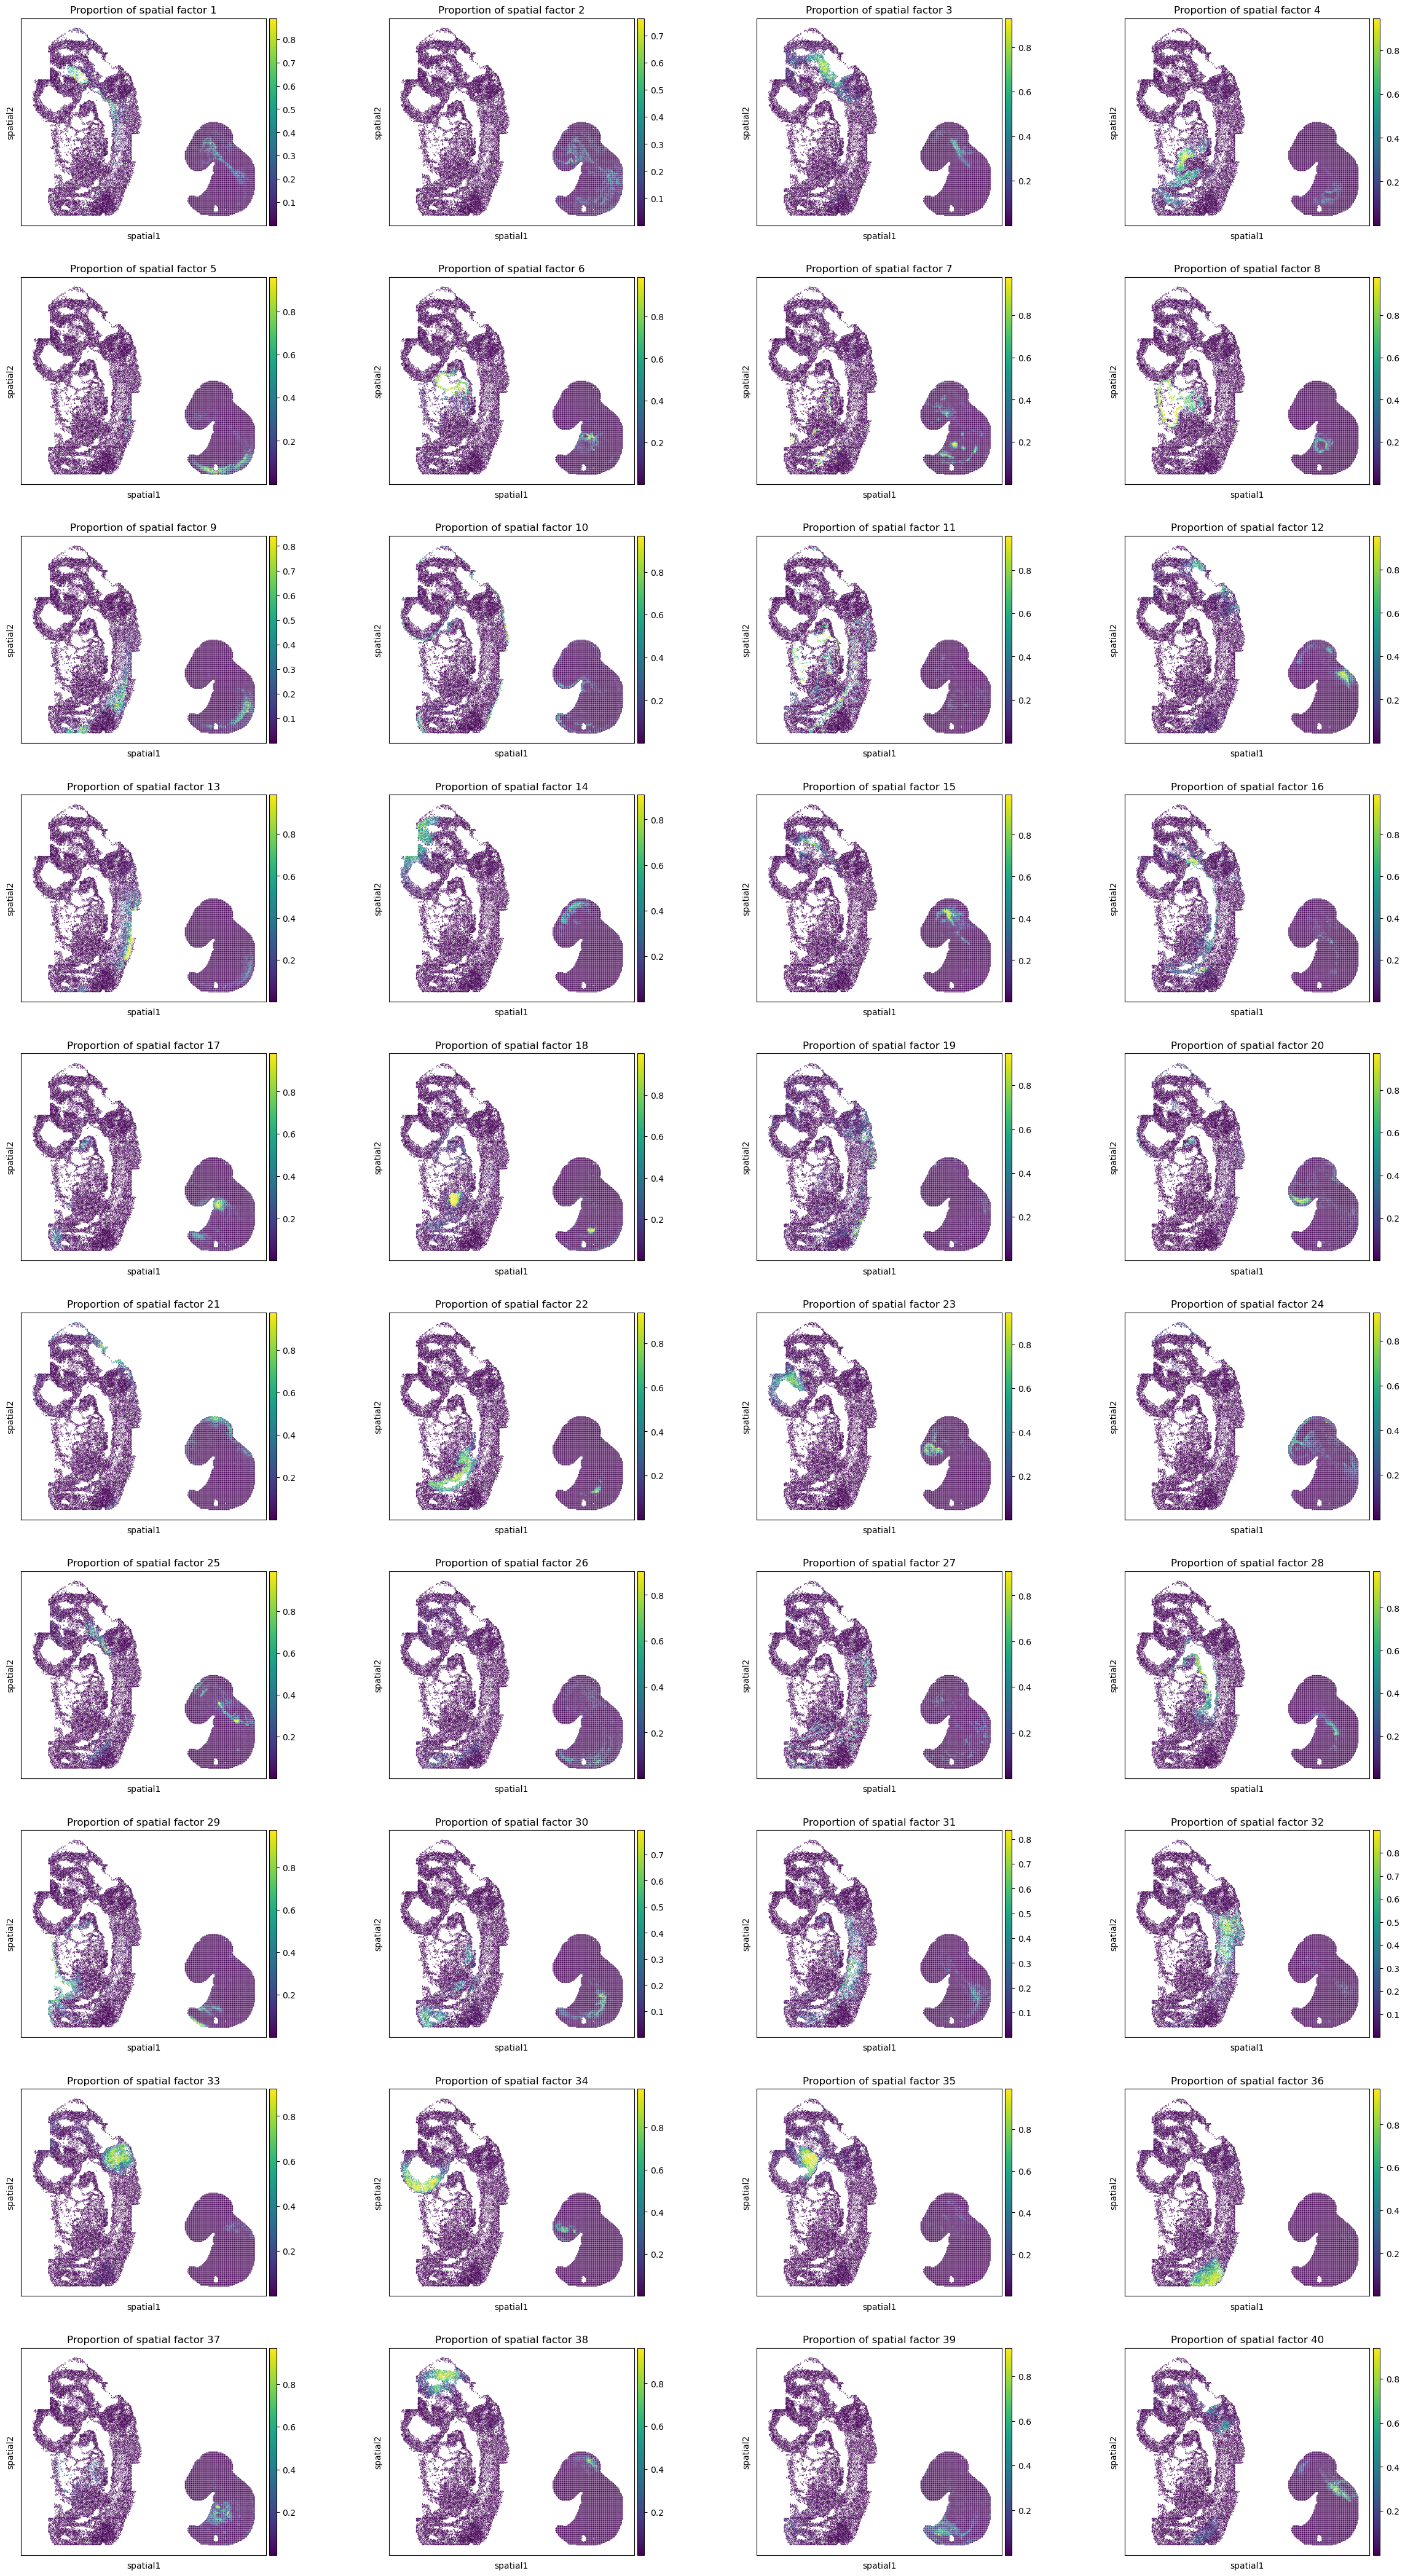

In [10]:
sc.pl.spatial(adata_full, color=["Proportion of spatial factor "+str(i+1) for i in range(40)], spot_size=1.)

### Spot representations and spatial domain identification

To visualize the spot representations learned by INSPIRE, we employ UMAP plots. The UMAP embedding is generated by first constructing a UMAP model using umap.UMAP, and then transforming the spot representations into two-dimensional coordinates using the fit_transform function from the umap package.

In [11]:
reducer = umap.UMAP(n_neighbors=30,
                    n_components=2,
                    metric="correlation",
                    n_epochs=None,
                    learning_rate=1.0,
                    min_dist=0.3,
                    spread=1.0,
                    set_op_mix_ratio=1.0,
                    local_connectivity=1,
                    repulsion_strength=1,
                    negative_sample_rate=5,
                    a=None,
                    b=None,
                    random_state=1234,
                    metric_kwds=None,
                    angular_rp_forest=False,
                    verbose=True)
embedding = reducer.fit_transform(adata_full.obsm['latent'])
adata_full.obsm["X_umap"] = embedding
adata_full.obs["slice"] = adata_full.obs["slice"].values.astype(str)

UMAP(angular_rp_forest=True, local_connectivity=1, metric='correlation', min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Wed May 28 19:41:28 2025 Construct fuzzy simplicial set
Wed May 28 19:41:28 2025 Finding Nearest Neighbors
Wed May 28 19:41:28 2025 Building RP forest with 12 trees
Wed May 28 19:41:30 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Wed May 28 19:41:40 2025 Finished Nearest Neighbor Search
Wed May 28 19:41:42 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed May 28 19:42:02 2025 Finished embedding


For visualizing UMAP plots, we utilizes the sc.pl.umap function from the Scanpy pipeline.

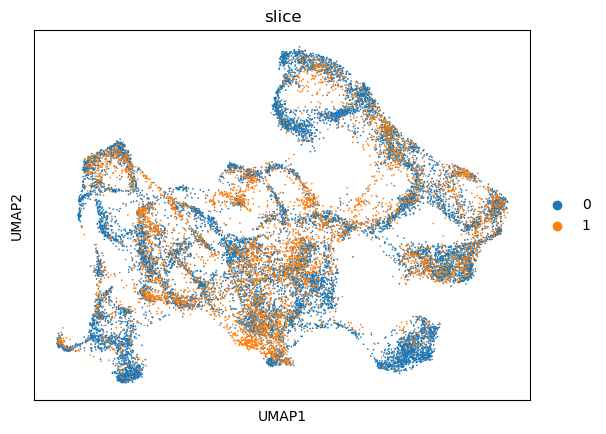

In [12]:
sc.pl.umap(adata_full, color=["slice"])

The learned spot representations enable the identification of spatial domains. When the number of spatial domains is known a priori, clustering is performed using a Gaussian Mixture Model implemented in the sklearn package. In the absence of such prior knowledge, spatial domains are identified using the Louvain clustering algorithm, implemented through the sc.pp.neighbors and sc.tl.louvain functions in the Scanpy package.

In [13]:
sc.pp.neighbors(adata_full, use_rep="latent", n_neighbors=30)
sc.tl.louvain(adata_full, resolution=.7)

Spatial domain assignments are visualized on both the UMAP embedding and the spatial coordinates of the spots using the sc.pl.umap and sc.pl.spatial functions from the Scanpy pipeline, respectively.

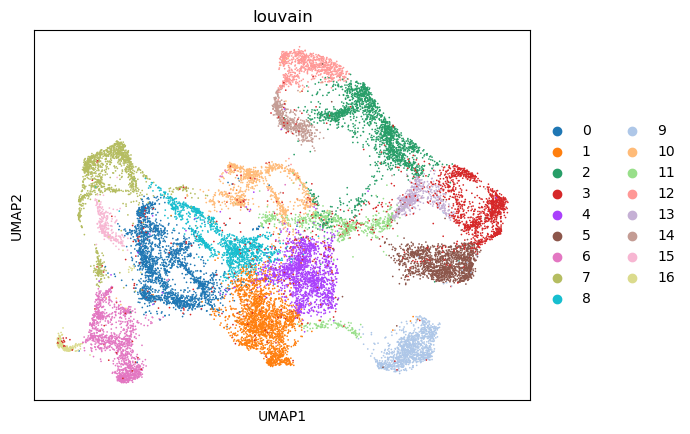

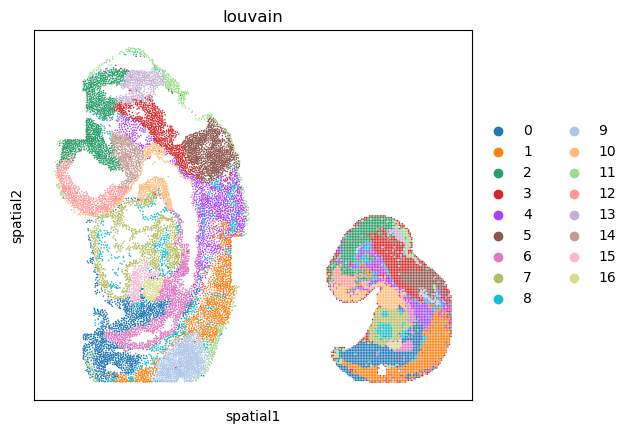

In [14]:
sc.pl.umap(adata_full, color=["louvain"])
sc.pl.spatial(adata_full, color=["louvain"], spot_size=1.)

Finally, we save the results from INSPIRE.

In [15]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/example_analyses/example_LGCN_data"
adata_full.write(res_path + "/adata_full_inspire.h5ad")
basis_df.to_csv(res_path + "/basis_df_inspire.csv")